## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub by clicking the link below. If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 


Access the [**Black Marble Nighttime Light Emissions**](https://us-ghg-center.github.io/ghgc-docs/user_data_notebooks/blackmarble-radiance-daygrid-v2nrt_User_Notebook.html) notebook in the US GHG Center JupyterHub. 

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Visual Comparison Across Time Periods](#visual-comparison-across-time-periods)
- [Map Out Selected Tiles](#map-out-selected-tiles)
- [Calculate Zonal Statistics](#calculate-zonal-statistics)
- [Time-Series Analysis](#time-series-analysis)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global
- **Spatial resolution**: 500m
- **Temporal extent**:  October 10, 2023 - Ongoing
- **Temporal resolution**: Daily
- **Unit**: Watts per square centimeter per steradian (W/cm²/sr)
- **Utility**: Climate Research

For more, visit the [Black Marble Nighttime Light Emissions](https://earth.gov/ghgcenter/data-catalog/blackmarble-radiance-daygrid-v2nrt) data overview page.  

## Approach

This notebook demonstrates how to visualize changes in a satellite-derived data product over time using STAC metadata and pre-rendered WMTS imagery. The steps below outline the workflow:

1. Connect to the GHGC STAC API
Use the `/stac` endpoint to access metadata for the collection of interest — in this case, `VIIRS_SNPP_DayNightBand_At_Sensor_Radiance`.
2. Determine Available Dates
Query the STAC collection to identify available temporal granularity and select two observation dates for comparison.
3. Compute `WMTS Tile Indices` for Region of Interest
Using a simple tile coordinate calculation (based on the EPSG:4326 tiling scheme), compute the TileMatrix, TileCol, and TileRow values that cover the bounding box for Cape Coral / Fort Myers.
4. Construct `WMTS URLs and Fetch Tiles`
Use the computed tile indices and selected timestamps to fetch image tiles from NASA GIBS via WMTS. Tiles are stitched into a single image per timestamp.
5. Visualize `Side-by-Side` in Matplotlib
Display the before/after imagery using matplotlib for visual comparison of the area of interest over time.

## About the Data
### Black Marble Nighttime Light Emissions
This dataset presents a 

For more information regarding this dataset, please visit the [U.S. Greenhouse Gas Center](https://earth.gov/ghgcenter).

## Terminology
Navigating data via the GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.
- `catalog`:    All datasets available at the `/stac` endpoint
- `collection`: A specific dataset, e.g. BlueFlux CO₂ and Methane Flux
- `item`:       One granule in the dataset, e.g. one daily file of carbon fluxes
- `asset`:      A variable available within the granule, e.g. net primary productivity or net ecosystem exchange
- `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets
- `Raster API`: Endpoint for fetching data itself, for imagery and statistics

# Install the Required Libraries
Required libraries are pre-installed on the GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests folium rasterstats pystac_client pandas matplotlib --quiet

In [1]:
import requests
import matplotlib.pyplot as plt
from pystac_client import Client
from IPython.display import display
from PIL import Image
from io import BytesIO

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the Black Marble Nighttime Light Emissions dataset is [**VIIRS_SNPP_DayNightBand_At_Sensor_Radiance**](https://earth.gov/ghgcenter/api/stac/collections/blueflux-ghgflux-daygrid-v1).*

**You can find the collection name of any dataset on the GHGC data portal by navigating to the dataset landing page within the data catalog. The collection name is the last portion of the dataset landing page's URL, and is also listed in the pop-up box after clicking "ACCESS DATA."*

In [ ]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://dev.ghg.center/api/stac"


# The collection name is used to fetch metadata from the STAC API.
COLLECTION_NAME = "VIIRS_SNPP_DayNightBand_At_Sensor_Radiance"

tilematrixset = "500m"
tilematrix = "2"
tilecol = "1"
tilerow = "1"

## Tile Index Calculation

In [3]:
# Input extent (lon_min, lon_max, lat_min, lat_max)
extent = [-82.0, -81.8, 26.0, 26.8]

tilematrixset = "500m"  # from your metadata
tilematrix = 2  # zoom level

def lonlat_to_tilexy(lon, lat, zoom):
    """
    Convert lon/lat to WMTS tile col/row for EPSG:4326 with tilematrixset 'GoogleMapsCompatible_Level8'
    """
    n = 2 ** zoom
    x = (lon + 180) / 360
    y = (90 - lat) / 180  # flipped because tiles start from top-left (lat=90)

    tile_x = int(x * n)
    tile_y = int(y * n)
    return tile_x, tile_y

# Lower-left corner tile indices (lon_min, lat_min)
min_tile_x, max_tile_y = lonlat_to_tilexy(extent[0], extent[2], tilematrix)

# Upper-right corner tile indices (lon_max, lat_max)
max_tile_x, min_tile_y = lonlat_to_tilexy(extent[1], extent[3], tilematrix)

print(f"tilematrixset = '{tilematrixset}'")
print(f"tilematrix (zoom level) = {tilematrix}")
print(f"tilecol range = {min_tile_x} to {max_tile_x}")
print(f"tilerow range = {min_tile_y} to {max_tile_y}")


tilematrixset = '500m'
tilematrix (zoom level) = 2
tilecol range = 1 to 1
tilerow range = 1 to 1


In [4]:
# Dates to compare
dates = ["2022-09-30T00:00:00Z", "2022-08-30T00:00:00Z"]

# Load collection
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(COLLECTION_NAME)
display(collection)

# WMTS base URL
wmts_base = "https://gibs-c.earthdata.nasa.gov/wmts/epsg4326/best/wmts.cgi"


<CollectionClient id=VIIRS_SNPP_DayNightBand_At_Sensor_Radiance>

# Creating Plot Side-by-Side Images

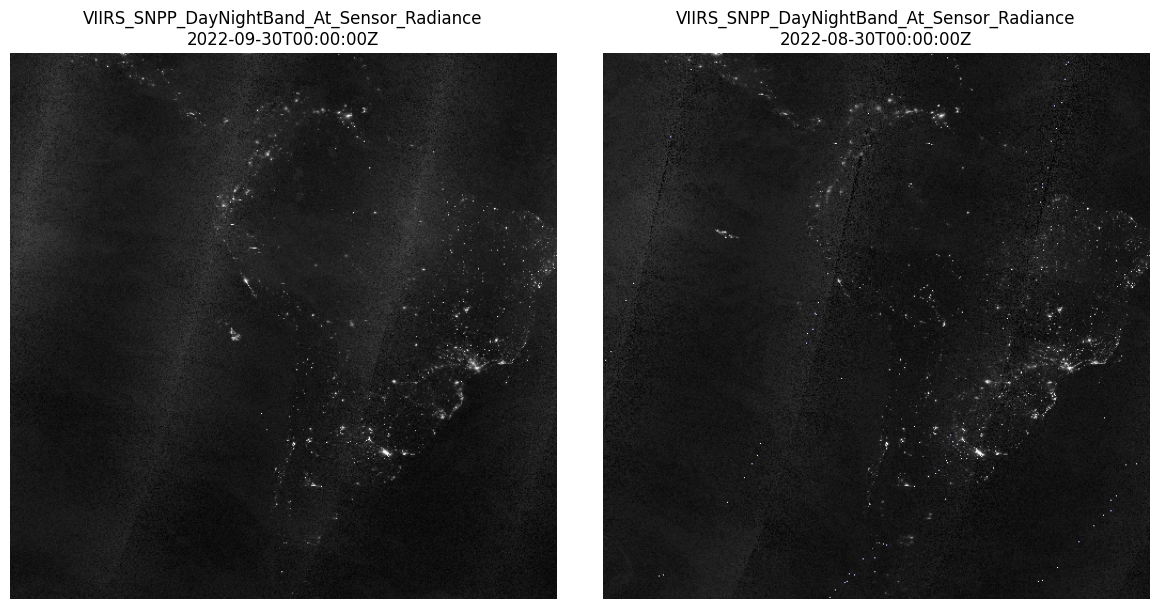

In [5]:
# Prepare subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax, date_str in zip(axs, dates):
    params = {
        "TIME": date_str,
        "layer": COLLECTION_NAME,
        "style": "default",
        "tilematrixset": tilematrixset,
        "Service": "WMTS",
        "Request": "GetTile",
        "Version": "1.0.0",
        "Format": "image/png",
        "TileMatrix": tilematrix,
        "TileCol": tilecol,
        "TileRow": tilerow
    }
    
    response = requests.get(wmts_base, params=params)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{COLLECTION_NAME}\n{date_str}")
    else:
        ax.text(0.5, 0.5, f"Failed to load\n{date_str}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Summary

In this notebook we have successfully completed the following steps for the STAC collection for the Black Marble Nighttime Light Emissions dataset:
1.	Install and import the necessary libraries 
2.	Fetch the collection from STAC collections using the appropriate endpoints
3.  Two WMTS tiles stitched and shown side-by-side via matplotlib.
4.	Map and compare nighttime light emissions for two distinctive days

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform). 